In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI SEBARAN GEMPA DARI KATALOG HYBRID INDONESIA
Menggunakan Cartopy untuk peta wilayah Indonesia dan sekitarnya
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeLocator, LatitudeLocator
import os

# =============================================
# 1. KONFIGURASI
# =============================================
CATALOG_CSV = "/Volumes/Extreme SSD/katalog/hybrid_catalog_filtered.csv"
OUTPUT_DIR = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/maps"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =============================================
# 2. BACA KATALOG
# =============================================
print("📂 Membaca katalog...")
df = pd.read_csv(CATALOG_CSV)
print(f"✅ Total event: {len(df)}")

# Tampilkan kolom yang tersedia
print(f"📋 Kolom: {df.columns.tolist()}")

# Deteksi kolom latitude dan longitude
lat_col = None
lon_col = None
mag_col = None
depth_col = None

for col in df.columns:
    col_lower = col.lower()
    if 'lat' in col_lower:
        lat_col = col
    elif 'lon' in col_lower:
        lon_col = col
    elif 'mag' in col_lower:
        mag_col = col
    elif 'depth' in col_lower:
        depth_col = col

if lat_col is None or lon_col is None:
    raise ValueError("❌ Kolom latitude/longitude tidak ditemukan!")

print(f"🌐 Kolom latitude : {lat_col}")
print(f"🌐 Kolom longitude: {lon_col}")
if mag_col:
    print(f"📏 Kolom magnitude: {mag_col}")
if depth_col:
    print(f"📏 Kolom depth    : {depth_col}")

# Konversi ke numerik (jika perlu)
df[lat_col] = pd.to_numeric(df[lat_col], errors='coerce')
df[lon_col] = pd.to_numeric(df[lon_col], errors='coerce')
if mag_col:
    df[mag_col] = pd.to_numeric(df[mag_col], errors='coerce')

# Buang data dengan koordinat NaN
df_clean = df.dropna(subset=[lat_col, lon_col])
print(f"✅ Data dengan koordinat valid: {len(df_clean)}")

# Filter dasar (opsional): batas wilayah Indonesia
# Indonesia: lintang -11° sampai 8°, bujur 94° sampai 141°
df_filtered = df_clean[
    (df_clean[lat_col] >= -12) & (df_clean[lat_col] <= 10) &
    (df_clean[lon_col] >= 92) & (df_clean[lon_col] <= 144)
]
print(f"✅ Data dalam wilayah Indonesia: {len(df_filtered)}")

# =============================================
# 3. BUAT PETA DENGAN CARTOPY
# =============================================
print("🗺️ Membuat peta sebaran gempa...")

# Proyeksi: Mercator untuk wilayah tropis
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 12))
ax = plt.axes(projection=proj)

# Set extent: fokus ke Indonesia dan sekitarnya
ax.set_extent([92, 144, -12, 10], crs=proj)

# Tambahkan fitur peta
ax.add_feature(cfeature.LAND, facecolor='#f5f5dc', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='#e0f0ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--', alpha=0.7)
ax.add_feature(cfeature.LAKES, facecolor='#e0f0ff', edgecolor='black', linewidth=0.3)
ax.add_feature(cfeature.RIVERS, linewidth=0.3, edgecolor='#87ceeb', alpha=0.5)

# Tambahkan grid
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# =============================================
# 4. PLOT EVENT DENGAN WARNA BERDASARKAN MAGNITUDE
# =============================================
if mag_col and mag_col in df_filtered.columns:
    # Filter magnitude valid
    df_mag = df_filtered.dropna(subset=[mag_col])
    magnitudes = df_mag[mag_col].values
    lats = df_mag[lat_col].values
    lons = df_mag[lon_col].values
    
    print(f"📊 Jumlah event dengan magnitude: {len(magnitudes)}")
    print(f"   Magnitude min: {np.min(magnitudes):.1f}")
    print(f"   Magnitude max: {np.max(magnitudes):.1f}")
    print(f"   Magnitude mean: {np.mean(magnitudes):.1f}")
    
    # Scatter plot dengan ukuran dan warna berdasarkan magnitude
    scatter = ax.scatter(
        lons, lats,
        c=magnitudes,
        s=(magnitudes - np.min(magnitudes) + 1) * 5,  # ukuran proporsional
        cmap='plasma',
        alpha=0.7,
        edgecolor='black',
        linewidth=0.2,
        transform=proj,
        vmin=np.min(magnitudes),
        vmax=np.max(magnitudes)
    )
    
    # Colorbar
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
    cbar.set_label('Magnitude', fontsize=12)
else:
    # Jika tidak ada kolom magnitude, plot titik biasa
    lats = df_filtered[lat_col].values
    lons = df_filtered[lon_col].values
    ax.scatter(lons, lats, s=5, c='red', alpha=0.5, transform=proj)

# =============================================
# 5. JUDUL DAN SIMPAN
# =============================================
ax.set_title('Sebaran Gempa Indonesia (Hybrid Catalog)', fontsize=16, pad=20)

# Simpan gambar
output_path = os.path.join(OUTPUT_DIR, 'sebaran_gempa_indonesia.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"✅ Peta tersimpan: {output_path}")

# =============================================
# 6. OPSIONAL: BUAT PETA DENGAN KEDALAMAN
# =============================================
if depth_col and depth_col in df_filtered.columns:
    print("\n🗺️ Membuat peta dengan warna berdasarkan kedalaman...")
    df_depth = df_filtered.dropna(subset=[depth_col])
    depths = df_depth[depth_col].values
    lats = df_depth[lat_col].values
    lons = df_depth[lon_col].values
    
    fig2 = plt.figure(figsize=(14, 12))
    ax2 = plt.axes(projection=proj)
    ax2.set_extent([92, 144, -12, 10], crs=proj)
    ax2.add_feature(cfeature.LAND, facecolor='#f5f5dc', edgecolor='black', linewidth=0.5)
    ax2.add_feature(cfeature.OCEAN, facecolor='#e0f0ff')
    ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax2.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--', alpha=0.7)
    
    scatter2 = ax2.scatter(
        lons, lats,
        c=depths,
        s=20,
        cmap='viridis_r',
        alpha=0.7,
        edgecolor='black',
        linewidth=0.2,
        transform=proj
    )
    cbar2 = fig2.colorbar(scatter2, ax=ax2, orientation='vertical', pad=0.05, shrink=0.7)
    cbar2.set_label('Kedalaman (km)', fontsize=12)
    
    ax2.set_title('Sebaran Gempa Indonesia (Kedalaman)', fontsize=16, pad=20)
    output_path2 = os.path.join(OUTPUT_DIR, 'sebaran_gempa_kedalaman.png')
    plt.savefig(output_path2, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Peta kedalaman tersimpan: {output_path2}")

# =============================================
# 7. STATISTIK
# =============================================
print("\n" + "="*70)
print("📊 STATISTIK KATALOG")
print("="*70)
print(f"Total event: {len(df)}")
print(f"Valid koordinat: {len(df_clean)}")
print(f"Dalam wilayah Indonesia: {len(df_filtered)}")
if mag_col:
    mag_valid = df_filtered.dropna(subset=[mag_col])[mag_col]
    print(f"Magnitudo - Min: {mag_valid.min():.2f}, Max: {mag_valid.max():.2f}, Mean: {mag_valid.mean():.2f}")
if depth_col:
    depth_valid = df_filtered.dropna(subset=[depth_col])[depth_col]
    print(f"Kedalaman - Min: {depth_valid.min():.2f} km, Max: {depth_valid.max():.2f} km, Mean: {depth_valid.mean():.2f} km")
print("="*70)

📂 Membaca katalog...
✅ Total event: 49842
📋 Kolom: ['datetime', 'latitude', 'longitude', 'magnitude', 'depth_km', 'source', 'event_id', 'year']
🌐 Kolom latitude : latitude
🌐 Kolom longitude: longitude
📏 Kolom magnitude: magnitude
📏 Kolom depth    : depth_km
✅ Data dengan koordinat valid: 49842
✅ Data dalam wilayah Indonesia: 40532
🗺️ Membuat peta sebaran gempa...
📊 Jumlah event dengan magnitude: 40532
   Magnitude min: 4.5
   Magnitude max: 9.1
   Magnitude mean: 4.8
✅ Peta tersimpan: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/maps/sebaran_gempa_indonesia.png

🗺️ Membuat peta dengan warna berdasarkan kedalaman...
✅ Peta kedalaman tersimpan: /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/maps/sebaran_gempa_kedalaman.png

📊 STATISTIK KATALOG
Total event: 49842
Valid koordinat: 49842
Dalam wilayah Indonesia: 40532
Magnitudo - Min: 4.50, Max: 9.10, Mean: 4.83
Kedalaman - Min: 0.30 km, Max: 150.00 km, Mean: 42.88 km


📂 Membaca katalog gempa...
✅ Jumlah data mentah: 49,842
✅ Setelah filter magnitudo > 0: 49,842
✅ Setelah filter koordinat: 49,842
🗺️ Membuat peta sebaran gempa...
✅ Peta berhasil disimpan: peta_sebaran_gempa_indonesia.png


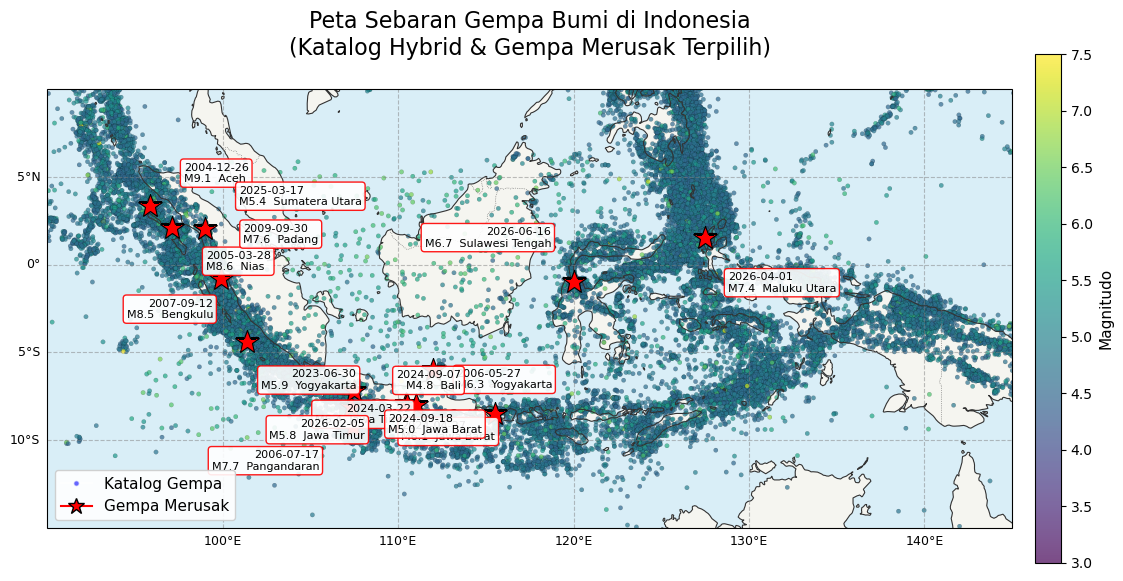

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
PETA SEBARAN GEMPA BUMI INDONESIA
- Sumber data: katalog hybrid (CSV)
- Menampilkan titik gempa dengan warna berdasarkan magnitudo
- Menandai gempa-gempa besar/merusak dengan bintang merah dan label
- Menggunakan Cartopy untuk peta dasar
"""

import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# =============================================
# 1. KONFIGURASI
# =============================================

# Path ke katalog gempa Anda
CATALOG_CSV = "/Volumes/Extreme SSD/katalog/hybrid_catalog_filtered.csv"

# Nama kolom (sesuaikan dengan struktur CSV Anda)
KOLOM_LAT = 'latitude'
KOLOM_LON = 'longitude'
KOLOM_MAG = 'magnitude'

# =============================================
# 2. BACA DAN BERSIHKAN DATA KATALOG
# =============================================

print("📂 Membaca katalog gempa...")
df = pd.read_csv(CATALOG_CSV)
print(f"✅ Jumlah data mentah: {len(df):,}")

# Bersihkan data: hanya magnitudo positif dan koordinat valid
if KOLOM_MAG in df.columns:
    df[KOLOM_MAG] = pd.to_numeric(df[KOLOM_MAG], errors='coerce')
    df = df[df[KOLOM_MAG] > 0]
    print(f"✅ Setelah filter magnitudo > 0: {len(df):,}")

df = df.dropna(subset=[KOLOM_LAT, KOLOM_LON])
print(f"✅ Setelah filter koordinat: {len(df):,}")

# =============================================
# 3. DAFTAR GEMPA MERUSAK (UNTUK LABEL)
# =============================================

# Format: [lintang, bujur, label, magnitudo]
gempa_merusak = [
    # ---- Gempa Bersejarah Besar ----
    [3.316, 95.854, "2004-12-26\nM9.1  Aceh", 9.1],
    [2.085, 97.108, "2005-03-28\nM8.6  Nias", 8.6],
    [-7.961, 110.446, "2006-05-27\nM6.3  Yogyakarta", 6.3],
    [-9.284, 107.419, "2006-07-17\nM7.7  Pangandaran", 7.7],
    [-4.438, 101.367, "2007-09-12\nM8.5  Bengkulu", 8.5],
    [-0.800, 99.880, "2009-09-30\nM7.6  Padang", 7.6],
    
    # ---- Gempa 2023-2026 (dari berita) ----
    [-8.0, 110.5, "2023-06-30\nM5.9  Yogyakarta", 5.9],
    [-8.1, 107.3, "2024-04-27\nM6.1  Jawa Barat", 6.1],
    [-6.0, 112.0, "2024-03-22\nM6.4  Jawa Timur", 6.4],
    [-7.2, 107.5, "2024-09-18\nM5.0  Jawa Barat", 5.0],
    [-8.5, 115.5, "2024-09-07\nM4.8  Bali", 4.8],
    [2.0, 99.0, "2025-03-17\nM5.4  Sumatera Utara", 5.4],
    [-8.0, 111.0, "2026-02-05\nM5.8  Jawa Timur", 5.8],
    [1.5, 127.5, "2026-04-01\nM7.4  Maluku Utara", 7.4],
    [-1.0, 120.0, "2026-06-16\nM6.7  Sulawesi Tengah", 6.7],
]

# Urutkan berdasarkan magnitudo (terbesar di atas)
gempa_merusak.sort(key=lambda x: x[3], reverse=True)

# =============================================
# 4. BUAT PETA DENGAN CARTOPY
# =============================================

print("🗺️ Membuat peta sebaran gempa...")

fig = plt.figure(figsize=(15, 11))
ax = plt.axes(projection=ccrs.PlateCarree())

# --- Tambahkan fitur peta ---
ax.add_feature(cfeature.LAND, facecolor='#f5f5f0')
ax.add_feature(cfeature.OCEAN, facecolor='#d9eef7')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#333')
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, edgecolor='#666')
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor='#aed6f1')

# --- Atur batas wilayah Indonesia ---
ax.set_extent([90, 145, -15, 10], crs=ccrs.PlateCarree())

# --- Tambahkan garis grid ---
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}

# --- Plot semua titik gempa dari katalog ---
if KOLOM_MAG in df.columns:
    sc = ax.scatter(
        df[KOLOM_LON], df[KOLOM_LAT],
        c=df[KOLOM_MAG],
        s=10,
        cmap='viridis',
        alpha=0.7,
        edgecolor='black',
        linewidth=0.1,
        transform=ccrs.PlateCarree(),
        vmin=3, vmax=7.5
    )
    cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.6)
    cbar.set_label('Magnitudo', fontsize=11)
else:
    ax.scatter(df[KOLOM_LON], df[KOLOM_LAT], s=5, color='blue', alpha=0.4, transform=ccrs.PlateCarree())

# --- Plot gempa merusak dengan label ---
# Pola offset untuk menghindari tumpang tindih label
offsets = [
    (1.2, 0.8), (1.2, -0.8), (-1.2, 0.8), (-1.2, -0.8),
    (0.8, 1.2), (0.8, -1.2), (-0.8, 1.2), (-0.8, -1.2),
    (1.8, 0.5), (1.8, -0.5), (-1.8, 0.5), (-1.8, -0.5),
]

for i, (lat, lon, label, mag) in enumerate(gempa_merusak):
    # Bintang merah dengan outline hitam
    ax.plot(
        lon, lat,
        marker='*',
        color='red',
        markersize=18,
        markeredgecolor='black',
        markeredgewidth=0.8,
        transform=ccrs.PlateCarree()
    )
    
    # Pilih offset berdasarkan indeks
    off_x, off_y = offsets[i % len(offsets)]
    # Perbesar offset untuk label yang lebih panjang
    if len(label) > 15:
        off_x *= 1.6
        off_y *= 1.6
    
    # Tambahkan teks label
    ax.text(
        lon + off_x, lat + off_y,
        label,
        transform=ccrs.PlateCarree(),
        fontsize=8,
        ha='left' if off_x > 0 else 'right',
        va='bottom' if off_y > 0 else 'top',
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="red",
            alpha=0.9
        )
    )

# --- Legenda ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Katalog Gempa',
           markerfacecolor='blue', markersize=4, alpha=0.6),
    Line2D([0], [0], marker='*', color='red', label='Gempa Merusak',
           markeredgecolor='black', markersize=12)
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=11, framealpha=0.9)

# --- Judul ---
plt.title('Peta Sebaran Gempa Bumi di Indonesia\n(Katalog Hybrid & Gempa Merusak)', 
          fontsize=16, pad=25)

# --- Simpan gambar ---
output_file = "peta_sebaran_gempa_indonesia.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Peta berhasil disimpan: {output_file}")

# Tampilkan (jika dijalankan di lingkungan interaktif)
# plt.show()

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
CEK KATALOG: APAKAH TERDAPAT GEMPA MERUSAK?
- Mencari gempa dengan magnitudo ≥ 6.0
- Mencari gempa dengan magnitudo ≥ 5.0 di tahun-tahun tertentu (2004-2009)
- Membandingkan dengan daftar gempa merusak terkenal
"""

import pandas as pd
from datetime import datetime

# =============================================
# 1. KONFIGURASI
# =============================================
CATALOG_CSV = "/Volumes/Extreme SSD/katalog/hybrid_catalog_filtered.csv"
LAT_COL = 'latitude'
LON_COL = 'longitude'
MAG_COL = 'magnitude'
TIME_COL = 'datetime'

# =============================================
# 2. BACA KATALOG
# =============================================
print("📂 Membaca katalog...")
df = pd.read_csv(CATALOG_CSV)
print(f"✅ Total data: {len(df):,} record")

# Pastikan kolom datetime ada
if TIME_COL not in df.columns:
    print(f"❌ Kolom '{TIME_COL}' tidak ditemukan. Coba deteksi otomatis...")
    for col in df.columns:
        if 'time' in col.lower() or 'datetime' in col.lower() or 'origin' in col.lower():
            TIME_COL = col
            break
    print(f"   Menggunakan kolom: '{TIME_COL}'")

# Konversi datetime
df['datetime'] = pd.to_datetime(df[TIME_COL], utc=True, format='ISO8601', errors='coerce')
df = df.dropna(subset=['datetime'])
df['year'] = df['datetime'].dt.year

# =============================================
# 3. FILTER GEMPA BESAR (M ≥ 6.0)
# =============================================
df_large = df[df[MAG_COL] >= 6.0].copy()
print(f"\n📊 Gempa dengan M ≥ 6.0: {len(df_large)} record")

if len(df_large) > 0:
    print("\n🔍 5 Gempa terbesar di katalog:")
    top5 = df_large.nlargest(5, MAG_COL)
    for _, row in top5.iterrows():
        print(f"   {row['datetime'].strftime('%Y-%m-%d %H:%M')} | M{row[MAG_COL]:.1f} | ({row[LAT_COL]:.2f}, {row[LON_COL]:.2f})")
else:
    print("⚠️ Tidak ada gempa dengan M ≥ 6.0 di katalog.")

# =============================================
# 4. CEK GEMPA MERUSAK TERKENAL
# =============================================
print("\n" + "="*60)
print("🔍 PENCARIAN GEMPA MERUSAK TERKENAL")
print("="*60)

# Daftar gempa merusak terkenal (waktu, koordinat, magnitudo)
famous_earthquakes = [
    {"name": "Aceh 2004", "year": 2004, "month": 12, "day": 26, "lat_min": 2.5, "lat_max": 4.0, "lon_min": 94.0, "lon_max": 97.0, "mag": 9.1},
    {"name": "Nias 2005", "year": 2005, "month": 3, "day": 28, "lat_min": 1.0, "lat_max": 3.0, "lon_min": 96.0, "lon_max": 98.0, "mag": 8.6},
    {"name": "Yogyakarta 2006", "year": 2006, "month": 5, "day": 27, "lat_min": -8.5, "lat_max": -7.5, "lon_min": 109.5, "lon_max": 111.0, "mag": 6.3},
    {"name": "Pangandaran 2006", "year": 2006, "month": 7, "day": 17, "lat_min": -10.0, "lat_max": -8.5, "lon_min": 106.5, "lon_max": 108.5, "mag": 7.7},
    {"name": "Bengkulu 2007", "year": 2007, "month": 9, "day": 12, "lat_min": -5.5, "lat_max": -3.5, "lon_min": 100.0, "lon_max": 102.5, "mag": 8.5},
    {"name": "Padang 2009", "year": 2009, "month": 9, "day": 30, "lat_min": -1.5, "lat_max": -0.2, "lon_min": 99.0, "lon_max": 100.5, "mag": 7.6},
    {"name": "Mentawai 2010", "year": 2010, "month": 10, "day": 25, "lat_min": -4.0, "lat_max": -2.5, "lon_min": 99.0, "lon_max": 101.0, "mag": 7.7},
    {"name": "Lombok 2018", "year": 2018, "month": 8, "day": 5, "lat_min": -9.0, "lat_max": -8.0, "lon_min": 115.5, "lon_max": 117.0, "mag": 6.9},
    {"name": "Palu 2018", "year": 2018, "month": 9, "day": 28, "lat_min": -1.5, "lat_max": 0.0, "lon_min": 119.0, "lon_max": 121.0, "mag": 7.5},
    {"name": "Sulawesi Tenggara 2026", "year": 2026, "month": 6, "day": 16, "lat_min": -2.0, "lat_max": 0.0, "lon_min": 119.0, "lon_max": 121.0, "mag": 6.7},
]

found = []
not_found = []

for eq in famous_earthquakes:
    # Cari dalam rentang koordinat dan tahun
    mask = (
        (df['year'] == eq['year']) &
        (df[LAT_COL] >= eq['lat_min']) & (df[LAT_COL] <= eq['lat_max']) &
        (df[LON_COL] >= eq['lon_min']) & (df[LON_COL] <= eq['lon_max'])
    )
    result = df[mask]
    if len(result) > 0:
        # Ambil yang terdekat dengan magnitudo
        if MAG_COL in result.columns:
            best = result.loc[result[MAG_COL].idxmax()]
            found.append({
                'name': eq['name'],
                'date': best['datetime'].strftime('%Y-%m-%d'),
                'mag': best[MAG_COL],
                'lat': best[LAT_COL],
                'lon': best[LON_COL],
                'count': len(result)
            })
        else:
            found.append({'name': eq['name'], 'count': len(result)})
    else:
        not_found.append(eq['name'])

# Tampilkan hasil
print(f"\n✅ Ditemukan di katalog: {len(found)}")
for item in found:
    mag_str = f"M{item['mag']:.1f}" if 'mag' in item else "?"
    print(f"   ✅ {item['name']}: {item['date']} | {mag_str} | ({item['lat']:.2f}, {item['lon']:.2f}) | {item['count']} record")

print(f"\n❌ Tidak ditemukan di katalog: {len(not_found)}")
for name in not_found:
    print(f"   ❌ {name}")

# =============================================
# 5. GEMPA MERUSAK PER TAHUN (INFORMASI TAMBAHAN)
# =============================================
print("\n" + "="*60)
print("📊 STATISTIK GEMPA BESAR PER TAHUN (M ≥ 6.0)")
print("="*60)

if len(df_large) > 0:
    yearly = df_large.groupby('year').size()
    print(f"Tahun dengan gempa M≥6.0 terbanyak: {yearly.idxmax()} ({yearly.max()} event)")
    print("\nDetail per tahun (dengan > 5 event):")
    for year, count in yearly.items():
        if count > 5:
            print(f"   {year}: {count} event")
else:
    print("Tidak ada data M≥6.0.")

📂 Membaca katalog...
✅ Total data: 49,842 record

📊 Gempa dengan M ≥ 6.0: 1035 record

🔍 5 Gempa terbesar di katalog:
   2004-12-26 00:58 | M9.1 | (3.29, 95.98)
   2005-03-28 16:09 | M8.6 | (2.08, 97.11)
   2012-04-11 08:38 | M8.6 | (2.33, 93.06)
   2007-09-12 11:10 | M8.4 | (-4.44, 101.37)
   2012-04-11 10:43 | M8.2 | (0.80, 92.46)

🔍 PENCARIAN GEMPA MERUSAK TERKENAL

✅ Ditemukan di katalog: 9
   ✅ Aceh 2004: 2004-12-26 | M9.1 | (3.29, 95.98) | 54 record
   ✅ Nias 2005: 2005-03-28 | M8.6 | (2.08, 97.11) | 592 record
   ✅ Yogyakarta 2006: 2006-05-26 | M6.3 | (-7.96, 110.45) | 9 record
   ✅ Pangandaran 2006: 2006-07-17 | M7.7 | (-9.28, 107.42) | 221 record
   ✅ Bengkulu 2007: 2007-09-12 | M8.4 | (-4.44, 101.37) | 107 record
   ✅ Padang 2009: 2009-09-30 | M7.7 | (-0.80, 99.88) | 88 record
   ✅ Mentawai 2010: 2010-10-25 | M7.8 | (-3.49, 100.08) | 216 record
   ✅ Lombok 2018: 2018-08-19 | M6.9 | (-8.32, 116.63) | 106 record
   ✅ Palu 2018: 2018-09-28 | M7.5 | (-0.26, 119.85) | 92 record

❌